In [2]:
from langgraph.graph import MessagesState
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
load_dotenv()

True

In [4]:
model = ChatMistralAI()

In [5]:
class ChatState(MessagesState):
    summary: str

In [6]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [7]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [8]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [9]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")



In [10]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

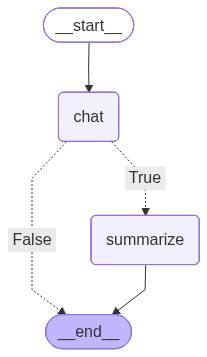

In [11]:
graph

In [12]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [13]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [14]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='062789b9-a567-410e-b168-cdb4b57a5cf3')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics (or quantum mechanics) is the branch of physics that studies the


In [15]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='062789b9-a567-410e-b168-cdb4b57a5cf3'), AIMessage(content='Quantum physics (or quantum mechanics) is the branch of physics that studies the behavior of matter and energy at the smallest scales—typically at the level of atoms and subatomic particles like electrons and photons. It departs radically from classical physics, introducing concepts that often seem counterintuitive.\n\n### Key Principles of Quantum Physics:\n\n1. **Wave-Particle Duality**\n   - Particles like electrons and photons exhibit both wave-like and particle-like properties.\n   - Example: Light behaves as a wave in diffraction experiments but as particles (photons) in the photoelectric effect.\n\n2. **Quantization**\n   - Certain physical properties, such as energy, are quantized—they can only take on specific discrete values.\n   - Example: Electrons in an atom occupy specific energy levels (quantum states), not a continuous range

In [16]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='062789b9-a567-410e-b168-cdb4b57a5cf3'), AIMessage(content='Quantum physics (or quantum mechanics) is the branch of physics that studies the behavior of matter and energy at the smallest scales—typically at the level of atoms and subatomic particles like electrons and photons. It departs radically from classical physics, introducing concepts that often seem counterintuitive.\n\n### Key Principles of Quantum Physics:\n\n1. **Wave-Particle Duality**\n   - Particles like electrons and photons exhibit both wave-like and particle-like properties.\n   - Example: Light behaves as a wave in diffraction experiments but as particles (photons) in the photoelectric effect.\n\n2. **Quantization**\n   - Certain physical properties, such as energy, are quantized—they can only take on specific discrete values.\n   - Example: Electrons in an atom occupy specific energy levels (quantum states), not a continuous range

In [17]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='062789b9-a567-410e-b168-cdb4b57a5cf3'), AIMessage(content='Quantum physics (or quantum mechanics) is the branch of physics that studies the behavior of matter and energy at the smallest scales—typically at the level of atoms and subatomic particles like electrons and photons. It departs radically from classical physics, introducing concepts that often seem counterintuitive.\n\n### Key Principles of Quantum Physics:\n\n1. **Wave-Particle Duality**\n   - Particles like electrons and photons exhibit both wave-like and particle-like properties.\n   - Example: Light behaves as a wave in diffraction experiments but as particles (photons) in the photoelectric effect.\n\n2. **Quantization**\n   - Certain physical properties, such as energy, are quantized—they can only take on specific discrete values.\n   - Example: Electrons in an atom occupy specific energy levels (quantum states), not a continuous range